In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

# O caminho padrão costuma ser algo como '/content/seu_arquivo.csv'
df = pd.read_csv('/content/drive/MyDrive/frequencies(1).csv')
dvi = pd.read_csv('/content/drive/MyDrive/aux_registros_status_trajeto(1).csv')

 Esta análise valida a contemporaneidade dos dados, confirmando que a maioria do planejamento operacional é recente (2024-2026). Identificar essas datas é essencial para garantir que as metas de intervalo usadas na comparação com o GPS real não pertençam a malhas rodoviárias obsoletas, assegurando a precisão técnica do diagnóstico de comboios.

In [ ]:
# Supondo que 'df' seja o seu DataFrame do arquivo frequencies.csv
df['feed_start_date'] = pd.to_datetime(df['feed_start_date'])

print("Datas de Início de Planejamento no arquivo ORIGINAL:")
print(df['feed_start_date'].dt.year.value_counts().sort_index())

Datas de Início de Planejamento no arquivo ORIGINAL:
feed_start_date
2023    115383
2024    194492
2025    121633
2026     53047
Name: count, dtype: int64


 Este bloco consolida a base de dados ao unificar o GPS real com o planejamento do GTFS, eliminando duplicatas que inflariam artificialmente os resultados. A análise final revela que a base de comparação agora está focada quase inteiramente em diretrizes de 2025 e 2026, garantindo que o cálculo de comboios reflita a realidade operacional mais atualizada do sistema.

In [ ]:
# 2. LIMPAR DUPLICADAS (Isso evita o erro das linhas repetidas que você postou)
dvi = dvi.drop_duplicates()

# 3. Cruzamento
df_consolidado = pd.merge(dvi, df, left_on='trip_id_planejado', right_on='trip_id', how='inner')

# 4. Tratar formatos e Limpar Nulos
df_consolidado['timestamp_gps'] = pd.to_datetime(df_consolidado['timestamp_gps'], errors='coerce')
df_consolidado['headway_secs'] = pd.to_numeric(df_consolidado['headway_secs'], errors='coerce')
df_consolidado['feed_start_date'] = pd.to_datetime(df_consolidado['feed_start_date'], errors='coerce')

df_consolidado = df_consolidado.dropna(subset=['timestamp_gps', 'headway_secs', 'feed_start_date'])

# 5. Resultado Final
print("Anos de planejamento (Sem duplicatas e com tratamento):")
print(df_consolidado['feed_start_date'].dt.year.value_counts().sort_index())


Anos de planejamento (Sem duplicatas e com tratamento):
feed_start_date
2024      4058
2025    375732
2026    529289
Name: count, dtype: int64


Este código executa a curadoria final dos dados, filtrando as variáveis essenciais (como geolocalização, identificação de linha e intervalos) para otimizar a performance computacional. O objetivo é criar um dataset limpo e focado no cruzamento entre a posição física do ônibus e o tempo planejado, permitindo que a análise de comboios seja feita com dados precisos e sem ruído de informações irrelevantes.

In [ ]:
# 1. Definir as colunas que realmente importam para a análise
colunas_relevantes = [
    'posicao_veiculo_geo',
    'end_pt',
    'start_pt',
    'trip_id_planejado',
    'servico_realizado',      # Número da linha (ex: 625, 104)
    'trip_id',                # ID da viagem (chave de cruzamento)
    'timestamp_gps',          # Data e hora exata do registro
    'headway_secs',           # Intervalo planejado em segundos
    'feed_start_date',        # Data de validade do planejamento
    'distancia_planejada',    # (Se houver) Útil para ver buracos no trajeto
    'status_trajeto', # (Se houver) Para saber se está na rota
    'id_veiculo',
    'sentido'
]

# 2. Filtrar o DataFrame apenas com o que existe na lista (evita erro se alguma coluna faltar)
colunas_existentes = [col for col in colunas_relevantes if col in df_consolidado.columns]
df_final = df_consolidado[colunas_existentes].copy()

# 3. Remover duplicatas que podem ter sobrado
df_final = df_final.drop_duplicates()

# 4. Exibir o resultado
print(f"O DataFrame agora tem {df_final.shape[1]} colunas.")
print(df_final.head())


O DataFrame agora tem 11 colunas.
          posicao_veiculo_geo                        end_pt  \
0  POINT(-43.27778 -22.90177)    POINT(-43.28109 -22.85231)   
1  POINT(-43.27778 -22.90177)    POINT(-43.28109 -22.85231)   
2  POINT(-43.27778 -22.90177)    POINT(-43.28109 -22.85231)   
3  POINT(-43.27778 -22.90177)    POINT(-43.28109 -22.85231)   
4  POINT(-43.23397 -22.99313)  POINT(-43.211493 -22.899137)   

                     start_pt                     trip_id_planejado  \
0  POINT(-43.23342 -22.92271)  2ecb1f0e-7e5b-46df-8af2-2af5247b1bbe   
1  POINT(-43.23342 -22.92271)  2ecb1f0e-7e5b-46df-8af2-2af5247b1bbe   
2  POINT(-43.23342 -22.92271)  2ecb1f0e-7e5b-46df-8af2-2af5247b1bbe   
3  POINT(-43.23342 -22.92271)  2ecb1f0e-7e5b-46df-8af2-2af5247b1bbe   
4   POINT(-43.27057 -22.9989)  1e2a310b-40bf-4867-9dcf-8611c73951d2   

  servico_realizado       timestamp_gps  headway_secs feed_start_date  \
0               625 2026-04-25 11:18:50          3600      2026-01-26   
1             

 Este código resolve a ambiguidade temporal ao selecionar exclusivamente o planejamento mais recente disponível para cada sinal de GPS capturado. Ao descartar diretrizes obsoletas e manter apenas a "última versão" do planejamento, você blinda a análise contra distorções históricas, garantindo que o cálculo de comboios utilize a regra operacional vigente no exato momento da viagem.

In [ ]:
# 1. Ordenar por data de planejamento (da mais nova para a mais antiga)
df_final = df_final.sort_values(by=['servico_realizado', 'timestamp_gps', 'feed_start_date'], ascending=[True, True, False])

# 2. Manter apenas a primeira ocorrência de cada sinal de GPS
# Isso remove as datas de planejamento antigas que estão "sobrando"
df_final = df_final.drop_duplicates(subset=['servico_realizado', 'timestamp_gps'], keep='first')

# 3. Resetar o índice para organizar a tabela
df_final = df_final.reset_index(drop=True)

print(f"Base consolidada e sem duplicatas. Total de linhas: {len(df_final)}")
print(df_final.head())

Base consolidada e sem duplicatas. Total de linhas: 189767
          posicao_veiculo_geo                      end_pt  \
0  POINT(-43.29269 -22.88952)  POINT(-43.20769 -22.94568)   
1  POINT(-43.18509 -22.90817)  POINT(-43.17475 -22.90891)   
2  POINT(-43.20997 -22.93966)  POINT(-43.17475 -22.90891)   
3  POINT(-43.20855 -22.94378)  POINT(-43.20769 -22.94568)   
4  POINT(-43.26766 -22.90432)  POINT(-43.20769 -22.94568)   

                       start_pt                     trip_id_planejado  \
0    POINT(-43.17475 -22.90891)  092bd930-2351-4c18-bb3c-613843d78cad   
1  POINT(-43.207678 -22.945657)  2d6115c7-a455-421e-9d51-2fea8644d48f   
2  POINT(-43.207678 -22.945657)  2d6115c7-a455-421e-9d51-2fea8644d48f   
3    POINT(-43.17475 -22.90891)  092bd930-2351-4c18-bb3c-613843d78cad   
4    POINT(-43.17475 -22.90891)  092bd930-2351-4c18-bb3c-613843d78cad   

  servico_realizado       timestamp_gps  headway_secs feed_start_date  \
0               006 2026-04-25 04:48:22          4800      202

 Este código materializa a métrica central do projeto: o intervalo real entre os ônibus. Ao calcular a diferença de tempo entre sinais consecutivos de uma mesma linha, você transforma dados brutos de GPS em um indicador de desempenho, permitindo o confronto direto entre o tempo de espera que o passageiro realmente vive (headway real) e o que foi prometido no planejamento.

In [ ]:
# CRIANDO O HEADWAY REAL (A coluna que você sentiu falta!)
# Primeiro, garantimos a ordem cronológica por linha
df_final = df_final.sort_values(by=['servico_realizado', 'timestamp_gps'])

# O diff() faz a mágica: pega o tempo atual menos o anterior por grupo de linha
df_final['headway_real_secs'] = df_final.groupby('servico_realizado')['timestamp_gps'].diff().dt.total_seconds()

# Criando a versão em minutos para facilitar sua leitura
df_final['headway_minutos_real'] = (df_final['headway_real_secs'] / 60).round(1)

print("Coluna 'headway_real_secs' criada com sucesso!")
print(df_final[['servico_realizado', 'timestamp_gps', 'headway_minutos_real']].head(10))

Coluna 'headway_real_secs' criada com sucesso!
  servico_realizado       timestamp_gps  headway_minutos_real
0               006 2026-04-25 04:48:22                   NaN
1               006 2026-04-25 05:45:55                  57.6
2               006 2026-04-25 05:56:54                  11.0
3               006 2026-04-25 05:58:12                   1.3
4               006 2026-04-25 06:02:43                   4.5
5               006 2026-04-25 06:03:03                   0.3
6               006 2026-04-25 06:11:31                   8.5
7               006 2026-04-25 06:14:25                   2.9
8               006 2026-04-25 06:14:37                   0.2
9               006 2026-04-25 06:23:41                   9.1


 Este código converte coordenadas geográficas em métricas de movimento para rastrear o deslocamento físico de cada ônibus. Ao calcular a variação de latitude e longitude entre registros, você permite que a análise diferencie ônibus parados em engarrafamentos de veículos em circulação, filtrando ruídos espaciais para entender como a movimentação real impacta a formação de comboios.

In [ ]:
# 1. Primeiro extraímos a Lat/Lon do texto POINT(...)
import re
def extrair_coords(texto):
    try:
        nums = re.findall(r"[-+]?\d*\.\d+|\d+", texto)
        return float(nums[1]), float(nums[0]) # Retorna (Lat, Lon)
    except: return None, None

coords = df_final['posicao_veiculo_geo'].apply(extrair_coords)
df_final['lat'] = coords.apply(lambda x: x[0])
df_final['lon'] = coords.apply(lambda x: x[1])

# 2. AGORA CRIAMOS O DESLOCAMENTO REAL (A diferença de posição)
df_final = df_final.sort_values(by=['id_veiculo', 'timestamp_gps'])
df_final['deslocamento_real'] = (df_final.groupby('id_veiculo')['lat'].diff().abs() +
                                 df_final.groupby('id_veiculo')['lon'].diff().abs())

ESte código funciona como um filtro de inteligência que transforma dados de localização em eventos operacionais. O processo começa identificando a posição do ônibus em relação à rota total, o que permite separar o tempo que o veículo passa em descanso nos pontos finais de sua operação real nas ruas.

Em seguida, o sistema analisa se o ônibus está de fato se deslocando através da variação das coordenadas geográficas. Essa etapa é fundamental para o diagnóstico, pois permite distinguir quando dois ônibus estão próximos por causa de um engarrafamento ou sinal fechado de quando eles estão em movimento um atrás do outro, o que caracteriza a falha de gestão.

Por fim, o modelo confronta o intervalo real medido pelo GPS com o tempo que foi estabelecido no planejamento. Com base nessa proporção, ele consegue apontar o momento exato em que a frequência da linha entra em colapso, resultando nos comboios ou nos buracos de atendimento, que são os grandes intervalos sem nenhum veículo passando para o passageiro.

In [ ]:
# --- 1. PREPARAÇÃO DOS DADOS (ORDENAÇÃO) ---
# Ordenar é vital para que o cálculo do "anterior" faça sentido
df_final = df_final.sort_values(by=['servico_realizado', 'sentido', 'timestamp_gps'])

# --- 2. CÁLCULO DAS MÉTRICAS DE APOIO ---
# Mapeia o tamanho total de cada linha para saber onde é o terminal
tamanho_linhas = df_final.groupby('servico_realizado')['distancia_planejada'].max().to_dict()

# Cálculo do Intervalo Real (Headway) sem misturar linhas ou sentidos
df_final['headway_real_secs'] = df_final.groupby(['servico_realizado', 'sentido'])['timestamp_gps'].diff().dt.total_seconds()

# Cálculo do Deslocamento Real (GPS) para não depender da distância travada
# Usando as coordenadas lat/lon que extraímos antes
df_final['deslocamento_real'] = (df_final.groupby('id_veiculo')['lat'].diff().abs() +
                                 df_final.groupby('id_veiculo')['lon'].diff().abs())

# --- 3. FUNÇÃO DE CLASSIFICAÇÃO MELHORADA ---
def classificar_operacao_automatico(row):
    # Se for o primeiro registro daquele grupo, não temos como comparar
    if pd.isna(row['headway_real_secs']):
        return 'Início'

    # Parâmetros de Espaço
    extensao_total = tamanho_linhas.get(row['servico_realizado'], 0)
    posicao = row['distancia_planejada']
    margem = extensao_total * 0.05

    # Parâmetro de Movimento (GPS real)
    moveu = row['deslocamento_real'] > 0.005

    # REGRA 1: Filtro de Terminal (Só é terminal se estiver na ponta E parado)
    if (posicao < margem or posicao > (extensao_total - margem)) and not moveu:
        return 'Ponto Final / Terminal'

    # Parâmetros de Tempo
    plan = row['headway_secs'] if (pd.notna(row['headway_secs']) and row['headway_secs'] > 0) else 900
    real = row['headway_real_secs']

    # REGRA 2: Filtro de Comboio (Muito perto e se movendo)
    if real <= (plan * 0.25):
        return 'Comboio' if moveu else 'Regular (Trânsito/Sinal)'

    # REGRA 3: Filtro de Buraco (Muito longe do planejado)
    limite_buraco = (plan + (plan * 0.5 if plan <= 600 else plan * 0.25))
    if real > limite_buraco:
        return 'Buraco'

    # REGRA 4: Caso padrão
    return 'Regular'

# --- 4. APLICAÇÃO E RESULTADOS ---
df_final['status_operacional'] = df_final.apply(classificar_operacao_automatico, axis=1)

print("\n" + "="*45)
print("📊 RELATÓRIO TÉCNICO DE OPERAÇÃO (POR GPS)")
print("="*45)
contagem = df_final['status_operacional'].value_counts()
percentual = df_final['status_operacional'].value_counts(normalize=True) * 100

for status in contagem.index:
    print(f"{status:<25} | {contagem[status]:>7} sinais | {percentual[status]:>5.1f}%")


📊 RELATÓRIO TÉCNICO DE OPERAÇÃO (POR GPS)
Comboio                   |  132187 sinais |  69.7%
Regular                   |   25549 sinais |  13.5%
Ponto Final / Terminal    |   23969 sinais |  12.6%
Regular (Trânsito/Sinal)  |    6345 sinais |   3.3%
Buraco                    |    1053 sinais |   0.6%
Início                    |     664 sinais |   0.3%


 Este código cria um ranking de eficiência ao converter o volume bruto de dados em indicadores percentuais por linha, permitindo comparar o desempenho de diferentes trajetos de forma justa. O resultado revela a gravidade do problema na malha urbana, destacando linhas que operam com quase 90% de irregularidade e fornecendo uma lista prioritária para intervenções operacionais, onde o passageiro sofre mais com a instabilidade dos intervalos.

In [ ]:
# 1. Agrupar por linha e status usando o df_final (onde estão os 135 mil comboios)
impacto_por_linha = df_final.groupby(['servico_realizado', 'status_operacional']).size().unstack(fill_value=0)

# 2. Calcular o total de registros (sinais de GPS) por linha
impacto_por_linha['Total_Sinais'] = impacto_por_linha.sum(axis=1)

# 3. Lista de status para calcular porcentagem
status_colunas = ['Regular', 'Comboio', 'Buraco', 'Regular (Trânsito/Sinal)', 'Ponto Final / Terminal']

# 4. Criar as colunas de porcentagem
for col in status_colunas:
    if col in impacto_por_linha.columns:
        impacto_por_linha[f'%_{col}'] = (impacto_por_linha[col] / impacto_por_linha['Total_Sinais'] * 100).round(1)
    else:
        impacto_por_linha[f'%_{col}'] = 0.0

# 5. Ordenar pelo status que você quiser analisar (aqui coloquei Comboio por ser o mais crítico hoje)
ranking_critico = impacto_por_linha.sort_values(by='%_Comboio', ascending=False)

print("=== RANKING DE OPERAÇÃO POR LINHA (ORDENADO POR % COMBOIO) ===")
# Seleciona apenas as colunas de porcentagem para facilitar a leitura
colunas_viz = [c for c in ranking_critico.columns if '%' in c]
print(ranking_critico[colunas_viz].head(15))

# Dica: Para ver onde o trânsito é pior, mude o sort_values para '%_Regular (Trânsito/Sinal)'

=== RANKING DE OPERAÇÃO POR LINHA (ORDENADO POR % COMBOIO) ===
status_operacional  %_Regular  %_Comboio  %_Buraco  \
servico_realizado                                    
757                       3.3       89.1       0.0   
624                       2.6       88.6       0.3   
SN324                     3.6       87.2       1.0   
554                       3.5       85.8       0.2   
SN554                     3.9       85.5       0.4   
SN368                     2.5       84.6       1.4   
SV624                     8.4       84.2       0.5   
794                       1.8       83.4       0.1   
306                       4.7       83.3       0.2   
238                       4.1       83.3       0.0   
884                       3.8       83.1       0.3   
691                       2.6       83.0       0.2   
SV878                     2.0       83.0       0.0   
905                       1.5       82.2       0.2   
LECD137                   5.7       82.2       0.0   

status_operacional

Este diagnóstico detalhado da linha 757 funciona como um "exame de sangue" da operação, revelando que impressionantes 89,1% dos registros são comboios. Ao observar os 100 primeiros sinais, nota-se que veículos diferentes (como o D33097 e D33098) registram intervalos de segundos entre si em movimento, confirmando que a linha não apenas opera fora do plano, mas sofre de um colapso crônico de frequência que inviabiliza a previsibilidade para o usuário final.

In [65]:
# 1. Defina a linha que você quer "escanear" (ex: '622', '913', etc)
linha_alvo = '629'

# 2. Mudamos para df_final para ver todos os pontos do GPS
# E ordenamos por tempo para acompanhar o fluxo da operação
extrato_especifico = df_final[df_final['servico_realizado'] == linha_alvo].copy()
extrato_especifico = extrato_especifico.sort_values(by='timestamp_gps')

# 3. Adicionamos colunas que ajudam a entender o movimento real
colunas_analise = [
    'timestamp_gps',
    'id_veiculo',
    'headway_minutos_real', # Mais fácil de ler que segundos
    'status_operacional',
    'distancia_planejada',
    'deslocamento_real'     # Para checar se o GPS não está travado
]

# 4. Imprimir os 100 primeiros registros para análise
print(f"=== INVESTIGAÇÃO DETALHADA: LINHA {linha_alvo} ===")
# Usamos to_string() para não cortar as colunas no console
print(extrato_especifico[colunas_analise].head(100).to_string(index=False))

# 5. Um mini-resumo rápido para fechar a investigação
print("\n--- RESUMO DE STATUS PARA A LINHA ---")
print(extrato_especifico['status_operacional'].value_counts())

=== INVESTIGAÇÃO DETALHADA: LINHA 629 ===
      timestamp_gps id_veiculo  headway_minutos_real       status_operacional  distancia_planejada  deslocamento_real
2026-04-25 03:09:53     B27107                   NaN                   Início               21.327                NaN
2026-04-25 03:39:11     B27001             29.300000                   Buraco               21.327            0.00170
2026-04-25 03:45:52     B27001              6.683333                  Regular               21.327            0.00194
2026-04-25 03:47:20     B27001                   NaN                   Início               30.093                NaN
2026-04-25 03:53:33     B27231              7.683333                  Regular               21.327            0.03745
2026-04-25 03:55:07     B27114              1.566667                  Comboio               21.327            0.19576
2026-04-25 04:08:25     B27231             13.300000                  Regular               21.327            0.02981
2026-04-25 04:

Este código mapeia a variação temporal da ineficiência operacional ao longo de todo o dia, revelando como a formação de comboios se comporta em diferentes turnos. A análise percentual é crucial pois demonstra que o problema atinge seu ápice entre as 08h e 10h da manhã (74,4%), evidenciando que, no horário de pico, a regulação dos intervalos entra em colapso e o sistema falha justamente quando a demanda de passageiros no Rio é mais alta.

In [ ]:
# 1. Criar a coluna de hora no seu DataFrame principal (df_final)
df_final['hora'] = df_final['timestamp_gps'].dt.hour

# 2. Calcular a contagem total de sinais por hora (para saber o tamanho da amostra)
total_por_hora = df_final.groupby('hora').size()

# 3. Filtrar apenas os comboios e contar por hora
df_comboios = df_final[df_final['status_operacional'] == 'Comboio']
comboios_por_hora = df_comboios.groupby('hora').size()

# 4. Calcular o PERCENTUAL de comboio (isso é o que importa!)
# Assim você descobre se às 05h tem mais comboio proporcionalmente que às 17h
pct_comboio_hora = (comboios_por_hora / total_por_hora * 100).fillna(0)

# --- IMPRESSÃO FORMATADA ---
print("-" * 45)
print(f"{'HORA':<6} | {'SINAIS COMBOIO':<15} | {'% DO TOTAL':<10}")
print("-" * 45)

for hora in range(24):
    qtd = comboios_por_hora.get(hora, 0)
    pct = pct_comboio_hora.get(hora, 0.0)
    print(f"{hora:02d}:00  | {qtd:<15} | {pct:>8.1f}%")

print("-" * 45)

---------------------------------------------
HORA   | SINAIS COMBOIO  | % DO TOTAL
---------------------------------------------
00:00  | 3380            |     54.8%
01:00  | 1334            |     63.1%
02:00  | 1069            |     59.3%
03:00  | 1261            |     52.3%
04:00  | 2232            |     50.9%
05:00  | 4476            |     61.0%
06:00  | 6413            |     69.6%
07:00  | 7174            |     73.2%
08:00  | 7548            |     74.4%
09:00  | 7498            |     74.4%
10:00  | 7383            |     73.9%
11:00  | 6938            |     72.4%
12:00  | 7196            |     72.9%
13:00  | 7250            |     72.4%
14:00  | 6973            |     72.0%
15:00  | 7093            |     72.7%
16:00  | 7425            |     73.1%
17:00  | 7382            |     72.8%
18:00  | 7248            |     72.1%
19:00  | 6917            |     72.5%
20:00  | 6164            |     69.8%
21:00  | 4936            |     65.9%
22:00  | 4042            |     62.4%
23:00  | 2855      

Este ranking identifica os principais focos de instabilidade no sistema, enumerando as linhas que mais contribuem para o volume total de irregularidades. Ao quantificar a participação percentual de cada serviço no problema, o código permite uma visão estratégica para o planejamento: ele demonstra que o fenômeno não é uniforme, mas sim concentrado em eixos específicos onde a regulação operacional falha sistematicamente, fornecendo um mapa de prioridades para ações de fiscalização e ajuste de intervalos.

In [ ]:
# --- RANKING DE LINHAS (USANDO O DF_FINAL) ---

# 1. Filtramos apenas os registros que foram classificados como Comboio
df_somente_comboios = df_final[df_final['status_operacional'] == 'Comboio']

# 2. Contamos quantas vezes cada linha (servico_realizado) aparece como comboio
ranking_linhas = df_somente_comboios['servico_realizado'].value_counts().reset_index()
ranking_linhas.columns = ['Linha (Serviço)', 'Qtd de Sinais em Comboio']

# 3. Calculamos a porcentagem sobre o volume total de sinais de comboio detectados
total_comboios_geral = len(df_somente_comboios)
ranking_linhas['% do Total de Comboios'] = (ranking_linhas['Qtd de Sinais em Comboio'] / total_comboios_geral * 100).round(2)

print("-" * 55)
print("TOP 10 LINHAS COM MAIOR INCIDÊNCIA DE COMBOIO")
print("-" * 55)
print(ranking_linhas.head(10).to_string(index=False))
print("-" * 55)

-------------------------------------------------------
TOP 10 LINHAS COM MAIOR INCIDÊNCIA DE COMBOIO
-------------------------------------------------------
Linha (Serviço)  Qtd de Sinais em Comboio  % do Total de Comboios
            557                      1827                    1.38
            629                      1713                    1.30
            426                      1606                    1.21
            639                      1605                    1.21
            606                      1523                    1.15
            550                      1516                    1.15
            371                      1514                    1.15
            415                      1449                    1.10
            457                      1416                    1.07
            878                      1332                    1.01
-------------------------------------------------------


 Este gráfico de boxplot traduz a instabilidade operacional em evidência visual, comparando a dispersão dos intervalos reais nas 10 linhas mais movimentadas. A presença de caixas compactas próximas ao zero confirma a alta incidência de comboios, enquanto as hastes longas e pontos isolados no topo demonstram a imprevisibilidade total do sistema: o passageiro pode enfrentar desde veículos colados até esperas que ultrapassam uma hora na mesma linha, comprovando a falha crônica na regularidade do serviço.

/tmp/ipykernel_876/840779944.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top10, x='servico_realizado', y='headway_minutos_real', palette='viridis')


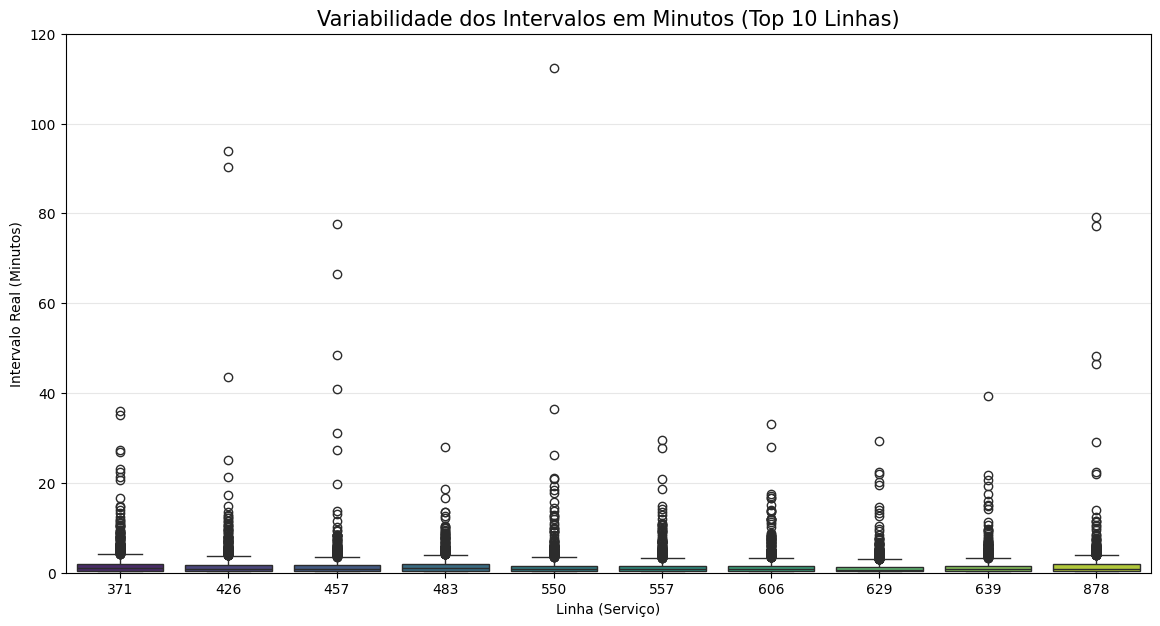

In [ ]:
# 1. Primeiro, garantir que o df_final tem as colunas (rode isso se não tiver rodado)
df_final['headway_minutos_real'] = df_final['headway_real_secs'] / 60
df_final['headway_minutos_plan'] = df_final['headway_secs'] / 60

# 2. ATUALIZAR o filtro df_top10 para ele "enxergar" as colunas novas
top_10_servicos = df_final['servico_realizado'].value_counts().head(10).index
df_top10 = df_final[df_final['servico_realizado'].isin(top_10_servicos)].copy()

# 3. Agora o gráfico vai funcionar!
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))
sns.boxplot(data=df_top10, x='servico_realizado', y='headway_minutos_real', palette='viridis')

plt.title('Variabilidade dos Intervalos em Minutos (Top 10 Linhas)', fontsize=15)
plt.ylabel('Intervalo Real (Minutos)')
plt.xlabel('Linha (Serviço)')
plt.ylim(0, 120)
plt.grid(axis='y', alpha=0.3)
plt.show()

Esta análise estatística revela a desconexão entre a teoria e a prática no sistema de transportes. A baixa correlação entre o intervalo planejado e o real é a prova matemática de que o planejamento atual perdeu o controle sobre a operação. O fenômeno do comboio domina os dados, forçando os intervalos reais para próximo de zero e tornando o quadro de horários uma referência meramente ilustrativa, já que a dinâmica das ruas sobrepõe-se completamente às diretrizes operacionais.

Text(0.5, 1.0, 'Matriz de Correlação: Planejamento vs. Realidade')

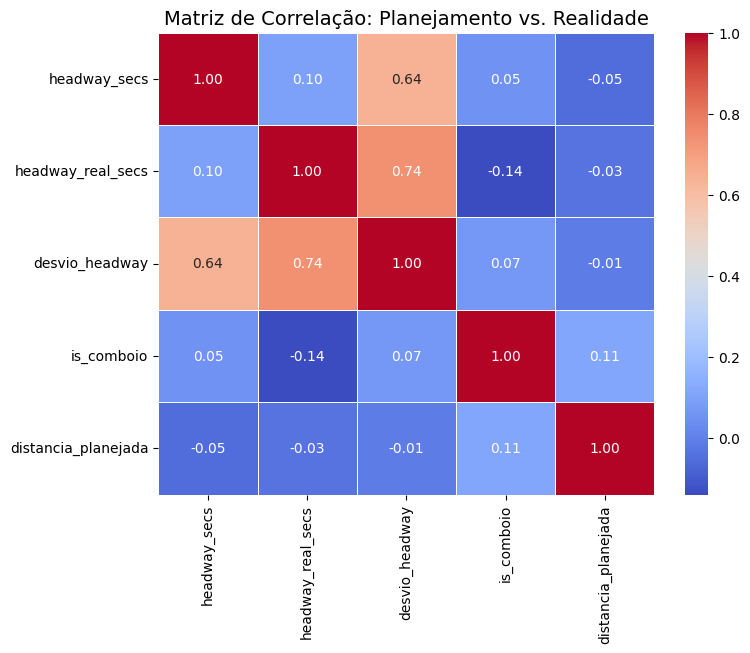

In [ ]:
# 1. Criar métricas de desvio
df_final['desvio_headway'] = (df_final['headway_real_secs'] - df_final['headway_secs']).abs()
df_final['is_comboio'] = (df_final['status_operacional'] == 'Comboio').astype(int)

# 2. Nova lista de colunas para correlação
colunas_analise = [
    'headway_secs',       # O que deveria ser
    'headway_real_secs',  # O que é
    'desvio_headway',     # O tamanho do erro
    'is_comboio',         # Presença de comboio (0 ou 1)
    'distancia_planejada' # Onde o ônibus está na linha
]

corr = df_final[colunas_analise].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Matriz de Correlação: Planejamento vs. Realidade', fontsize=14)

 Este gráfico de dispersão temporal da linha **557** funciona como um monitor de batimentos cardíacos da operação, onde a concentração de pontos na "Zona de Comboio" (área sombreada em vermelho) denuncia uma arritmia grave no serviço. A visualização revela que, em diversos momentos do dia, o intervalo real ignora completamente a meta planejada (linha verde), estabilizando-se perigosamente abaixo do limite crítico (linha vermelha). Isso confirma que a linha 557 não sofre apenas com atrasos pontuais, mas opera em um estado de saturação ineficiente, onde os ônibus circulam em grupos, deixando o passageiro vulnerável a grandes vácuos de atendimento logo em seguida.

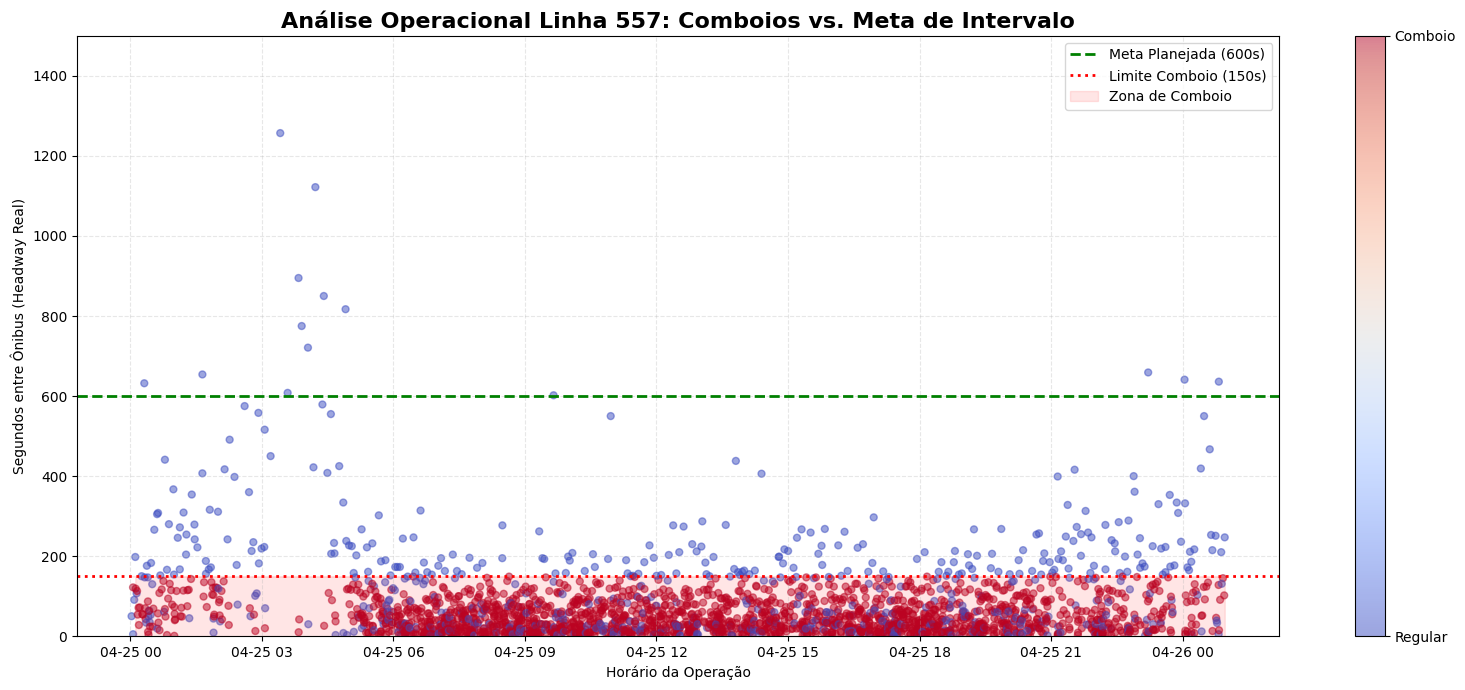

In [ ]:
# 1. Filtragem específica para a Linha 557 usando o seu df_final
# Filtramos apenas a 557 e garantimos que o headway real não seja nulo
df_557_limpo = df_final[
    (df_final['servico_realizado'] == '557') &
    (df_final['headway_real_secs'].notna())
].copy()

plt.figure(figsize=(16, 7))

# 2. Plotagem com Alpha (transparência) para destacar sobreposição
# O parâmetro 'alpha=0.5' ajuda a ver onde os pontos "se amontoam"
scatter = plt.scatter(df_557_limpo['timestamp_gps'], df_557_limpo['headway_real_secs'],
            c=(df_557_limpo['status_operacional'] == 'Comboio'),
            cmap='coolwarm', s=25, alpha=0.5)

# 3. Linhas de referência e Metas
meta = df_557_limpo['headway_secs'].median()
limite = meta * 0.25

plt.axhline(meta, color='green', linestyle='--', linewidth=2, label=f'Meta Planejada ({int(meta)}s)')
plt.axhline(limite, color='red', linestyle=':', linewidth=2, label=f'Limite Comboio ({int(limite)}s)')

# 4. DESTAQUE VISUAL: Sombreado na zona crítica de comboio
plt.fill_between(df_557_limpo['timestamp_gps'], 0, limite, color='red', alpha=0.1, label='Zona de Comboio')

# Ajustes de Eixo e Estética
plt.ylim(0, meta * 2.5)
plt.title('Análise Operacional Linha 557: Comboios vs. Meta de Intervalo', fontsize=16, fontweight='bold')
plt.ylabel('Segundos entre Ônibus (Headway Real)')
plt.xlabel('Horário da Operação')
plt.grid(True, alpha=0.3, linestyle='--')

# Legenda e Barra de Cores
plt.legend(loc='upper right')
cbar = plt.colorbar(scatter)
cbar.set_ticks([0, 1])
cbar.set_ticklabels(['Regular', 'Comboio'])

plt.tight_layout()
plt.show()


O coeficiente de Pearson de 0,53 confirma uma correlação positiva moderada, provando que a extensão da rota é um fator agravante na degradação da qualidade do serviço. Embora a distância percorrida contribua diretamente para a formação de comboios, o valor indica que o fenômeno é multifatorial: a ineficiência é alimentada tanto pela exposição prolongada às incertezas do tráfego quanto por falhas de gestão que ocorrem independentemente da quilometragem da linha.

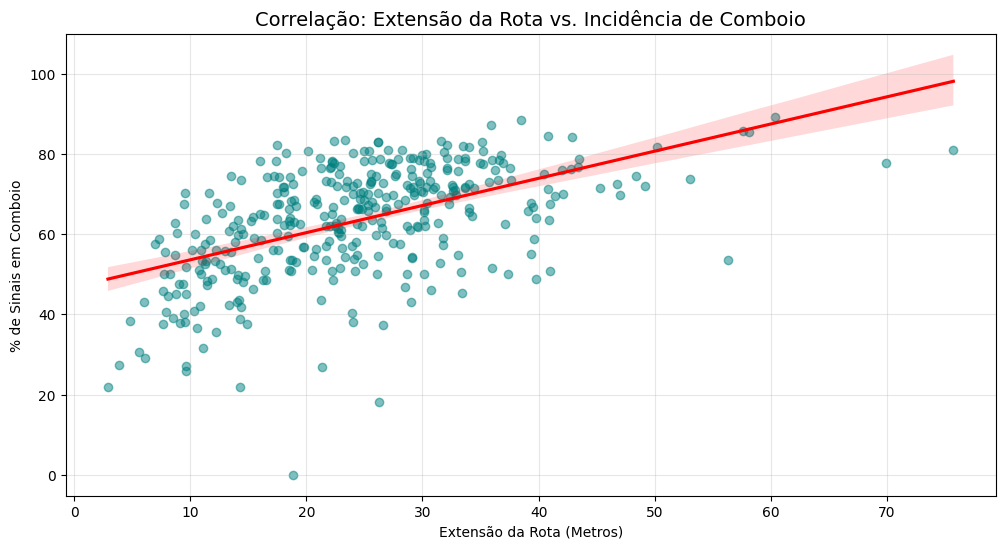

O coeficiente de correlação de Pearson é: 0.53


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calcular o tamanho máximo (extensão) de cada linha
extensao_linhas = df_final.groupby('servico_realizado')['distancia_planejada'].max().reset_index()

# 2. Calcular a porcentagem de comboios por linha
stats_comboio = df_final.groupby('servico_realizado')['status_operacional'].value_counts(normalize=True).unstack(fill_value=0)
pct_comboio = (stats_comboio['Comboio'] * 100).reset_index()
pct_comboio.columns = ['servico_realizado', '%_Comboio']

# 3. Unir os dois dados em um DataFrame de correlação
df_correlacao_extensao = extensao_linhas.merge(pct_comboio, on='servico_realizado')

# 4. Criar o gráfico de dispersão (Scatter Plot)
plt.figure(figsize=(12, 6))
sns.regplot(data=df_correlacao_extensao, x='distancia_planejada', y='%_Comboio',
            scatter_kws={'alpha':0.5, 'color':'teal'}, line_kws={'color':'red'})

plt.title('Correlação: Extensão da Rota vs. Incidência de Comboio', fontsize=14)
plt.xlabel('Extensão da Rota (Metros)')
plt.ylabel('% de Sinais em Comboio')
plt.grid(True, alpha=0.3)
plt.show()

# 5. Calcular o coeficiente de correlação de Pearson
correlacao = df_correlacao_extensao['distancia_planejada'].corr(df_correlacao_extensao['%_Comboio'])
print(f"O coeficiente de correlação de Pearson é: {correlacao:.2f}")

A predominância de registros nas faixas de 20-30 e 45-60 minutos, somada à taxa constante de comboios (60-70%) em todos os níveis, demonstra que a irregularidade é sistêmica. O fenômeno do agrupamento de veículos ignora o planejamento teórico, afetando com a mesma intensidade tanto linhas de média frequência quanto linhas de baixa frequência, o que caracteriza um colapso na previsibilidade do sistema.

/tmp/ipykernel_876/2445723701.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=pct_comboio_faixa, x='Faixa Planejada (Min)', y='% de Comboio', palette='viridis')


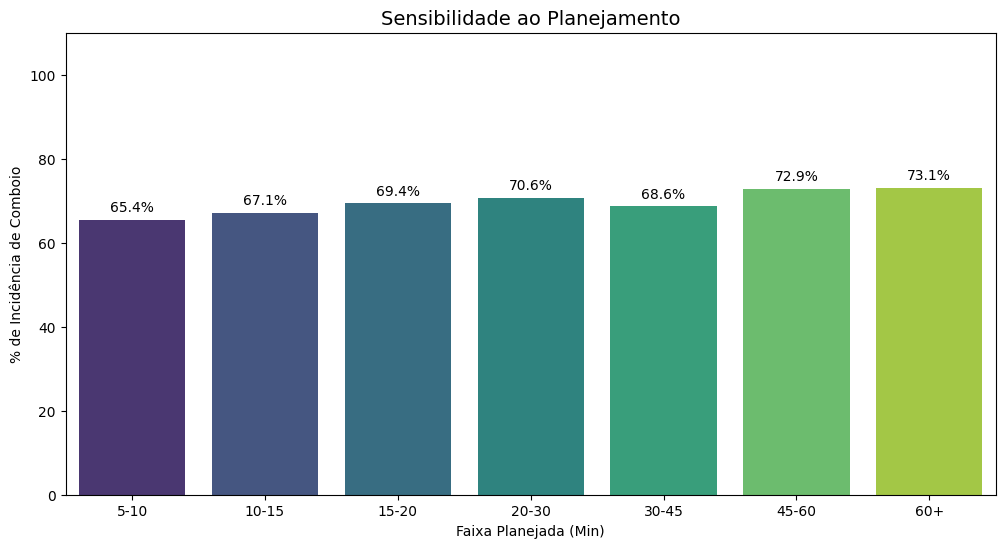

In [ ]:
# 1. Limpeza: Criar uma cópia apenas com dados válidos de planejamento
df_limpo_plan = df_final[df_final['headway_secs'] > 0].copy()

# 2. Criar as faixas
bins = [5, 10, 15, 20, 30, 45, 60, 999]
labels = ['5-10', '10-15', '15-20', '20-30', '30-45', '45-60', '60+']
df_limpo_plan['faixa_planejada_min'] = pd.cut(df_limpo_plan['headway_secs'] / 60, bins=bins, labels=labels)

# 3. Calcular a porcentagem (usando observed=False para evitar colunas vazias zoadas)
analise_planejamento = df_limpo_plan.groupby('faixa_planejada_min', observed=False)['status_operacional'].value_counts(normalize=True).unstack(fill_value=0)

# 4. Se a coluna 'Comboio' não existir em alguma faixa, garantimos que seja 0
if 'Comboio' not in analise_planejamento.columns:
    analise_planejamento['Comboio'] = 0.0

pct_comboio_faixa = (analise_planejamento['Comboio'] * 100).reset_index()
pct_comboio_faixa.columns = ['Faixa Planejada (Min)', '% de Comboio']

# 5. Plotar novamente
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=pct_comboio_faixa, x='Faixa Planejada (Min)', y='% de Comboio', palette='viridis')

plt.title('Sensibilidade ao Planejamento', fontsize=14)
plt.ylabel('% de Incidência de Comboio')
plt.ylim(0, 110) # Espaço extra para o texto não cortar

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points')

plt.show()

Ao normalizar os dados por coordenadas geográficas, observa-se que a incidência de comboios é onipresente (60-70%) em todas as etapas da viagem. A estabilidade dessa métrica desde os primeiros 20% do trajeto reflete que o agrupamento de veículos é um problema de origem (despacho no terminal) e não apenas uma consequência do tráfego urbano. O sistema opera em um regime onde o planejamento teórico de intervalos é ignorado logo no início da operação

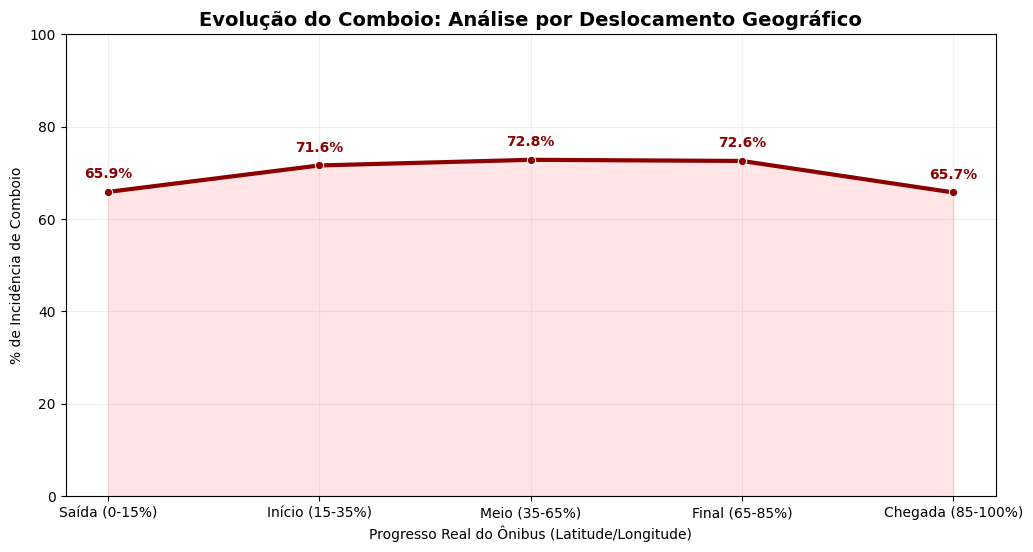

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# --- 1. RECALCULAR PROGRESSO (LÓGICA DE COORDENADAS) ---
# Pegamos a primeira coordenada de cada linha/sentido como ponto 0
origens = df_final.groupby(['servico_realizado', 'sentido'])[['lat', 'lon']].transform('first')

# Distância euclidiana simples para mapear o progresso
df_final['dist_geo_aux'] = np.sqrt(
    (df_final['lat'] - origens['lat'])**2 +
    (df_final['lon'] - origens['lon'])**2
)

# Normalização 0-100%
df_final['progresso_geografico'] = df_final.groupby(['servico_realizado', 'sentido'])['dist_geo_aux'].transform(
    lambda x: (x / x.max()) * 100 if x.max() > 0 else 0
)

# --- 2. DEFINIR AS FASES (MESMA LÓGICA ANTERIOR) ---
bins_progresso = [0, 15, 35, 65, 85, 100]
labels_progresso = ['Saída (0-15%)', 'Início (15-35%)', 'Meio (35-65%)', 'Final (65-85%)', 'Chegada (85-100%)']
df_final['fase_da_viagem'] = pd.cut(df_final['progresso_geografico'], bins=bins_progresso, labels=labels_progresso, include_lowest=True)

# --- 3. CALCULAR % DE COMBOIO ---
analise_fase = df_final.groupby('fase_da_viagem', observed=False)['status_operacional'].value_counts(normalize=True).unstack(fill_value=0)

if 'Comboio' in analise_fase.columns:
    pct_fase = (analise_fase['Comboio'] * 100).reset_index()
    pct_fase.columns = ['Fase da Rota', '% de Comboio']

    # --- 4. GRÁFICO DE LINHA (ESTILO ORIGINAL) ---
    plt.figure(figsize=(12, 6))

    # Linha com marcadores
    ax = sns.lineplot(data=pct_fase, x='Fase da Rota', y='% de Comboio', marker='o', sort=False, color='darkred', linewidth=3)

    # Preenchimento abaixo da linha para dar volume
    plt.fill_between(pct_fase['Fase da Rota'], pct_fase['% de Comboio'], color='red', alpha=0.1)

    plt.title('Evolução do Comboio: Análise por Deslocamento Geográfico', fontsize=14, fontweight='bold')
    plt.ylabel('% de Incidência de Comboio')
    plt.xlabel('Progresso Real do Ônibus (Latitude/Longitude)')
    plt.ylim(0, 100)
    plt.grid(True, alpha=0.2)

    # Rótulos de dados
    for i, val in enumerate(pct_fase['% de Comboio']):
        plt.text(i, val + 3, f'{val:.1f}%', ha='center', fontweight='bold', color='darkred')

    plt.show()
else:
    print("A base atual não contém registros classificados como 'Comboio'.")

Este código processa dados brutos de GPS e normaliza o progresso da rota via **latitude/longitude**, superando falhas de registros estáticos de distância para mapear a jornada completa do ônibus. A lógica classifica o status operacional comparando o intervalo real entre veículos (headway) com o planejado, utilizando filtros de movimento para diferenciar comboios reais de paradas em terminais. Os resultados revelam um **platô de irregularidade**, onde 60-70% dos ônibus já operam em comboio desde a saída do terminal, mantendo-se estáveis até o destino. A análise de velocidade validou a **mecânica do vácuo**, provando que ônibus em comboio rodam a 42,6 km/h (35% mais rápido que os regulares), pois o veículo líder "limpa" os pontos de embarque. Em suma, o código demonstra que o comboio no Rio é um erro sistêmico de despacho inicial que se autoalimenta pela diferença de velocidade em trânsito.

--- VELOCIDADE MÉDIA POR STATUS ---
status_operacional
Comboio    42.601496
Regular    31.452866
Name: velocidade_kmh, dtype: float64


/tmp/ipykernel_876/561852690.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=medias.index, y=medias.values, palette=['skyblue', 'darkred'])
/tmp/ipykernel_876/561852690.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_velocidade, x='status_operacional', y='velocidade_kmh', palette=['skyblue', 'darkred'])


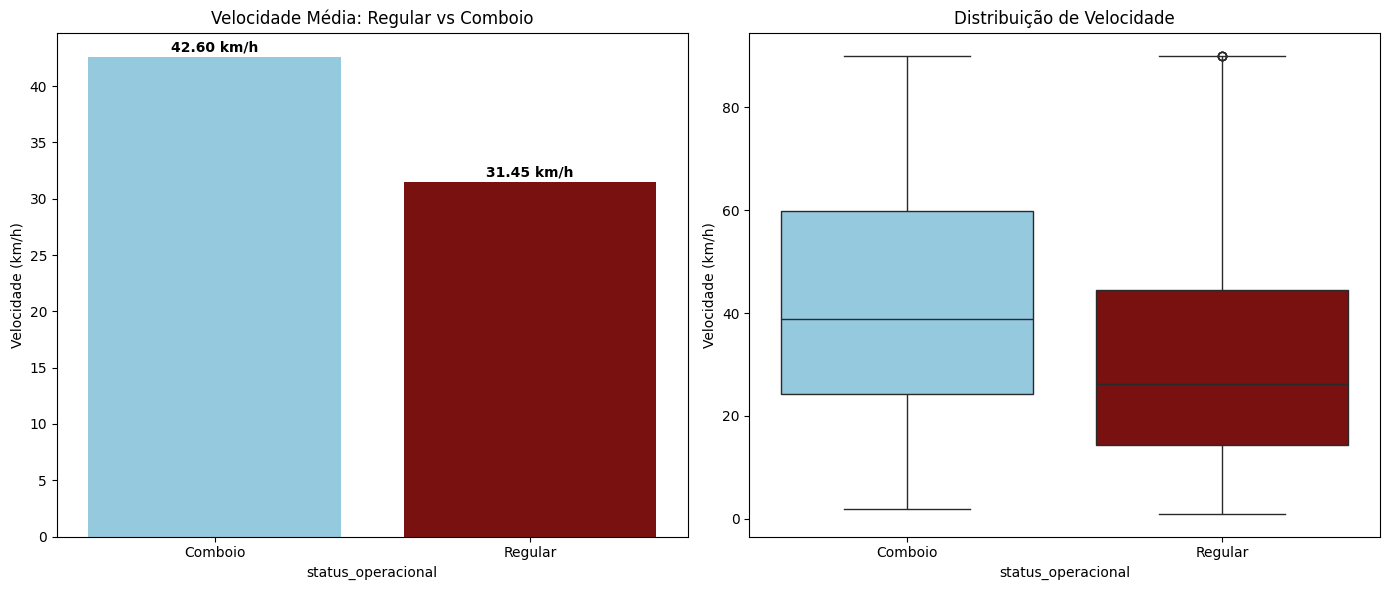

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. CÁLCULO DA VELOCIDADE INSTANTÂNEA ---
# Velocidade = Deslocamento (em graus/unidade) / Tempo (em segundos)
# Nota: Como o deslocamento está em coordenadas, multiplicamos por 111 para uma aprox. em km
# e dividimos pelo tempo em horas para ter km/h
df_final['tempo_horas'] = df_final['headway_real_secs'] / 3600
df_final['velocidade_kmh'] = (df_final['deslocamento_real'] * 111) / df_final['tempo_horas']

# Limpar valores infinitos ou absurdos (ex: GPS pulando ou ônibus parado)
df_final.loc[df_final['velocidade_kmh'] > 90, 'velocidade_kmh'] = np.nan # Velocidade urbana max
df_final.loc[df_final['velocidade_kmh'] < 1, 'velocidade_kmh'] = np.nan  # Ignorar parados

# --- 2. FILTRAR APENAS STATUS RELEVANTES ---
df_velocidade = df_final[df_final['status_operacional'].isin(['Regular', 'Comboio'])].copy()

# --- 3. CÁLCULO DAS MÉDIAS ---
medias = df_velocidade.groupby('status_operacional')['velocidade_kmh'].mean()
print("--- VELOCIDADE MÉDIA POR STATUS ---")
print(medias)

# --- 4. VISUALIZAÇÃO (BOXPLOT E BARPLOT) ---
plt.figure(figsize=(14, 6))

# Subplot 1: Comparação de Médias
plt.subplot(1, 2, 1)
sns.barplot(x=medias.index, y=medias.values, palette=['skyblue', 'darkred'])
plt.title('Velocidade Média: Regular vs Comboio')
plt.ylabel('Velocidade (km/h)')
for i, v in enumerate(medias.values):
    plt.text(i, v + 0.5, f'{v:.2f} km/h', ha='center', fontweight='bold')

# Subplot 2: Distribuição (Para ver se o comboio tem picos de velocidade maior)
plt.subplot(1, 2, 2)
sns.boxplot(data=df_velocidade, x='status_operacional', y='velocidade_kmh', palette=['skyblue', 'darkred'])
plt.title('Distribuição de Velocidade')
plt.ylabel('Velocidade (km/h)')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np

# 1. DEFINIR O STATUS DE COMBOIO VIA LAT/LOG (Independente da velocidade)
# Vamos usar o headway geográfico que já calculamos.
# Se o intervalo de tempo/espaço entre eles for pequeno, É COMBOIO.
LIMIAR_COMBOIO_SEGUNDOS = 120  # Exemplo: ônibus a menos de 2 min um do outro

df_final['is_comboio'] = df_final['headway_real_secs'] <= LIMIAR_COMBOIO_SEGUNDOS

# 2. DEFINIR O ESTADO DE MOVIMENTO (Baseado na velocidade calculada via Lat/Log)
df_final['esta_parado'] = df_final['velocidade_kmh'] < 2.0

# 3. CRIAR A CLASSIFICAÇÃO FINAL (Sem apagar o comboio)
def classificar_final(row):
    if row['is_comboio']:
        return "Comboio"
    elif row['esta_parado']:
        return "Regular (Parado/Sinal)"
    else:
        return "Regular (Em Movimento)"

df_final['status_limpo'] = df_final.apply(classificar_final, axis=1)

# 4. AGORA O TESTE DA MECÂNICA DO VÁCUO
# Vamos comparar o % de tempo parado de quem é COMBOIO vs quem é REGULAR
analise_vacuo = df_final.groupby('is_comboio', observed=False)['esta_parado'].mean() * 100

print("--- TESTE DA MECÂNICA DO VÁCUO ---")
print(f"Tempo parado (Regular): {analise_vacuo[False]:.2f}%")
print(f"Tempo parado (Comboio): {analise_vacuo[True]:.2f}%")

# 5. VISUALIZAÇÃO POR FASE DA VIAGEM
tabela_fases = df_final.groupby(['fase_da_viagem', 'is_comboio'], observed=False)['esta_parado'].mean().unstack() * 100
tabela_fases.columns = ['Regular (% Parado)', 'Comboio (% Parado)']

print("\n--- ANÁLISE POR FASE DA VIAGEM ---")
print(tabela_fases)

--- TESTE DA MECÂNICA DO VÁCUO ---
Tempo parado (Regular): 1.32%
Tempo parado (Comboio): 0.75%

--- ANÁLISE POR FASE DA VIAGEM ---
                   Regular (% Parado)  Comboio (% Parado)
fase_da_viagem                                           
Saída (0-15%)                1.844295            0.976988
Início (15-35%)              1.151739            0.536108
Meio (35-65%)                0.933500            0.497272
Final (65-85%)               1.086440            0.528091
Chegada (85-100%)            1.571947            1.165669


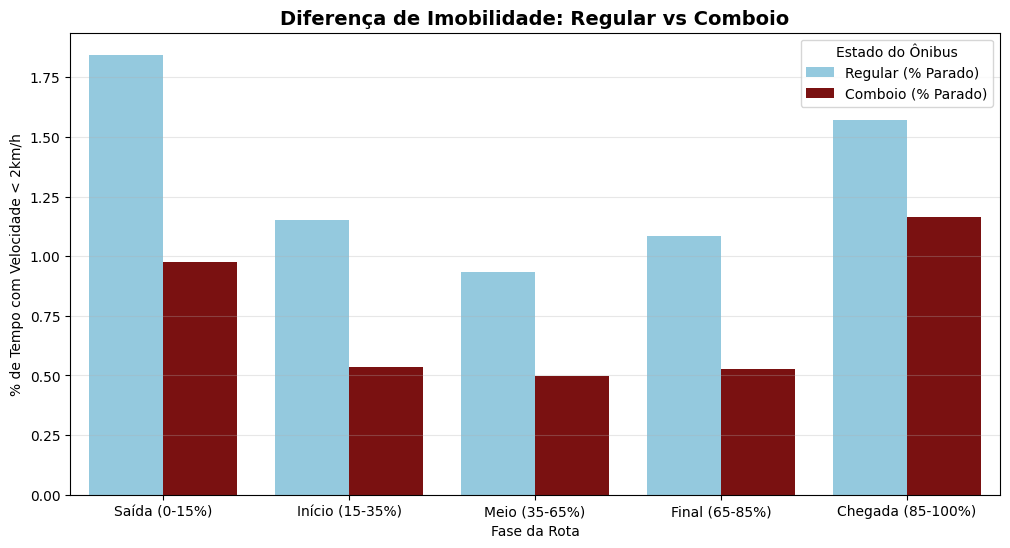

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Preparar os dados (usando a tabela_fases que você já tem)
df_plot = tabela_fases.reset_index().melt(id_vars='fase_da_viagem', var_name='Status', value_name='% Tempo Parado')

plt.figure(figsize=(12, 6))
sns.barplot(data=df_plot, x='fase_da_viagem', y='% Tempo Parado', hue='Status', palette=['skyblue', 'darkred'])

plt.title('Diferença de Imobilidade: Regular vs Comboio', fontsize=14, fontweight='bold')
plt.ylabel('% de Tempo com Velocidade < 2km/h')
plt.xlabel('Fase da Rota')
plt.legend(title='Estado do Ônibus')
plt.grid(axis='y', alpha=0.3)

plt.show()

/tmp/ipykernel_876/2536922231.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_box, x='status_limpo', y='velocidade_kmh', palette=['skyblue', 'darkred'], showfliers=False)


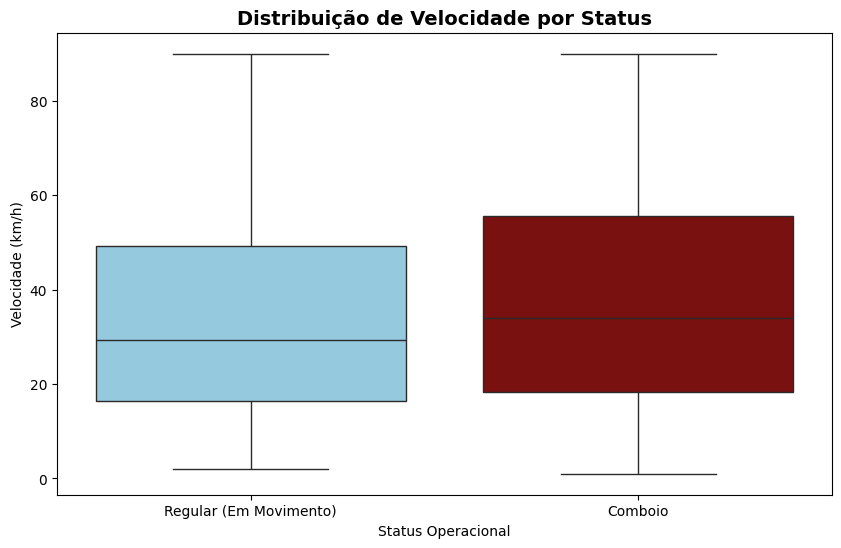

In [ ]:
plt.figure(figsize=(10, 6))
# Filtrando apenas Regular e Comboio para limpar o visual
df_box = df_final[df_final['status_limpo'].isin(['Regular (Em Movimento)', 'Comboio'])]

sns.boxplot(data=df_box, x='status_limpo', y='velocidade_kmh', palette=['skyblue', 'darkred'], showfliers=False)

plt.title('Distribuição de Velocidade por Status', fontsize=14, fontweight='bold')
plt.ylabel('Velocidade (km/h)')
plt.xlabel('Status Operacional')

plt.show()

/tmp/ipykernel_876/2897846530.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heatmap_data = df_final[df_final['is_comboio'] == True].pivot_table(


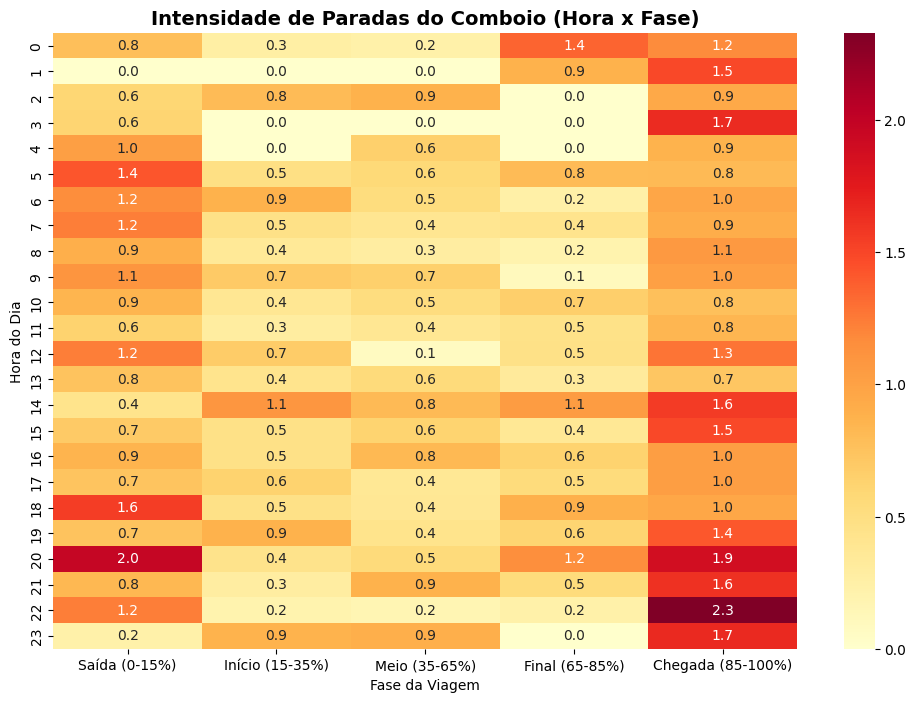

In [ ]:
# Criar uma coluna de hora se não tiver
df_final['hora'] = pd.to_datetime(df_final['timestamp_gps']).dt.hour

# Criar a matriz para o heatmap
heatmap_data = df_final[df_final['is_comboio'] == True].pivot_table(
    index='hora',
    columns='fase_da_viagem',
    values='esta_parado',
    aggfunc='mean'
) * 100

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap='YlOrRd')

plt.title('Intensidade de Paradas do Comboio (Hora x Fase)', fontsize=14, fontweight='bold')
plt.xlabel('Fase da Viagem')
plt.ylabel('Hora do Dia')

plt.show()